<a href="https://colab.research.google.com/github/STAHA17/Thesis/blob/main/sMoE_UNet_1_09_05_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# sMoE U-Net — Exact Paper Reproduction
### Rule-Based Spatial Mixture-of-Experts U-Net for Explainable Edge Detection
**arXiv: 2602.05100v2** | Dogga et al., 2026

---

## Cross-Verification Summary (paper vs code)

| Section | Item | Status |
|---------|------|--------|
| §2.1 | Sobel 3×3 kernels, fixed (non-learnable) | ✅ Exact |
| §2.1 | Context Expert: dilated 3×3, dilation=2 | ✅ Exact |
| §2.1 | Boundary Expert: pointwise 1×1 conv | ✅ Exact |
| §2.1 | Gate G(E) = σ(Conv1×1(resize(E))), scalar per pixel | ✅ Exact |
| §2.1 | sMoE on 3 skip connections only (enc2/3/4); enc1 plain | ✅ Exact |
| Fig.1 | Encoder 3→64→128→256→512→1024 | ✅ Exact |
| Fig.1 | Decoder ×2 upsample + concat + conv | ✅ Exact |
| §2.2 | x1 = Sobel E, x2 = σ(U-Net logit) | ✅ Exact |
| §2.2 | Gaussian MF: μ = exp(−(x−c)²/2σ²), trainable c,σ | ✅ Exact |
| §2.2 | Firing: wi = μi,1(x1)·μi,2(x2) | ✅ Exact |
| §2.2 | Defuzz: Y = Σ(wi/Σwj)·yi (normalized avg, NOT softmax) | ✅ Exact |
| §5.2 | Rule centers init: R1(0.85,0.85) R2(0.15,0.85) R3(0.15,0.15) R4(0.85,0.15) | ✅ Exact |
| §5.2 | Rule 4 negative weight init (a=-0.5) | ✅ Exact |
| §3.1 | BSDS500: 200/100/200 split, batch=4, Adam lr=1e-4 | ✅ Exact |
| §3.1 | Augmentation: rotation + horizontal flip | ✅ Exact |
| §3.2 | L = λ·BCE + (1−λ)·Dice, λ=0.5 | ✅ Exact |
| §3.2 | Distillation: MSE(TSK_out, σ(unet_logit.detach())) | ✅ Exact |
| §3.1 | **NO LR scheduler** — paper specifies Adam lr=1e-4 only | ✅ Fixed |
| §3.2 | **NO pos_weight** in BCE — paper does not mention it | ✅ Fixed |


In [2]:
# ============================================================
# CELL 1: Runtime check
# ============================================================
import torch, sys
print("Python:", sys.version)
print("Torch :", torch.__version__)
print("CUDA  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch : 2.10.0+cu128
CUDA  : True
GPU   : Tesla T4
VRAM  : 15.6 GB
Device: cuda


In [3]:
# ============================================================
# CELL 2: Install dependencies
# ============================================================
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q numpy matplotlib opencv-python-headless scipy Pillow tqdm scikit-learn
print("✅ Dependencies installed")


✅ Dependencies installed


In [4]:
# ============================================================
# CELL 3: Imports & configuration
# Paper §3.1 hyperparameters — exact values only
# ============================================================
import os, warnings
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import scipy.io

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from sklearn.metrics import average_precision_score, precision_recall_curve

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED);  np.random.seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# ── Paper §3.1 exact hyperparameters ────────────────────────
BATCH_SIZE    = 4        # paper: "batch size of 4"
LEARNING_RATE = 1e-4     # paper: "learning rate of 1e-4"
LAMBDA_BCE    = 0.5      # paper Eq.(2): λ = 0.5
IMG_SIZE      = 256      # paper: 256×256 input
N_RULES       = 4        # paper §2.2: R = 4 rules
BASE_CH       = 64       # paper Fig.1: base = 64 channels

# Training budget (paper doesn't specify — use validation-based stopping)
MAX_EPOCHS    = 120
PATIENCE      = 20       # early stop patience

WORK_DIR = "/content/drive/MyDrive/smoe_unet_exact"
os.makedirs(WORK_DIR, exist_ok=True)

print(f"Config: batch={BATCH_SIZE} | lr={LEARNING_RATE} | λ={LAMBDA_BCE} | img={IMG_SIZE}")
print(f"Work dir: {WORK_DIR}")
print("✅ Config ready")


Config: batch=4 | lr=0.0001 | λ=0.5 | img=256
Work dir: /content/drive/MyDrive/smoe_unet_exact
✅ Config ready


In [5]:
# ============================================================
# CELL 4: Download BSDS500 from GitHub
# ============================================================
print("Downloading BSDS500 dataset from GitHub...")

import os
import subprocess

# Method 1: Using git clone (recommended for full repo access)
github_repo = "https://github.com/BIDS/BSDS500.git"
target_dir = "/content/BSDS500"

if not os.path.exists(target_dir):
    print(f"Cloning repository from {github_repo}...")
    result = subprocess.run(["git", "clone", github_repo, target_dir],
                          capture_output=True, text=True)
    if result.returncode == 0:
        print("✅ Repository cloned successfully")
    else:
        print(f"❌ Git clone failed: {result.stderr}")
        print("Trying alternative method...")
else:
    print(f"Directory {target_dir} already exists")

# Check the data directory structure
data_dir = "/content/BSDS500/BSDS500/data"
if os.path.exists(data_dir):
    print(f"\n✅ BSDS500 data found at: {data_dir}")
    print("\nContents:")
    for item in os.listdir(data_dir)[:10]:  # Show first 10 items
        print(f"  - {item}")
    if len(os.listdir(data_dir)) > 10:
        print(f"  ... and {len(os.listdir(data_dir)) - 10} more items")
else:
    print(f"\n⚠️ Data directory not found at expected path")
    print("Searching for data folder...")
    for root, dirs, files in os.walk("/content/BSDS500"):
        if "data" in dirs:
            data_path = os.path.join(root, "data")
            print(f"✅ Found data at: {data_path}")
            break

print("\n📁 Dataset structure:")
!ls -la /content/BSDS500/BSDS500/ 2>/dev/null || ls -la /content/BSDS500/

Directory /content/BSDS500 already exists

✅ BSDS500 data found at: /content/BSDS500/BSDS500/data

Contents:
  - groundTruth
  - images

📁 Dataset structure:
total 16
drwxr-xr-x 4 root root 4096 May  9 17:20 .
drwxr-xr-x 7 root root 4096 May  9 17:20 ..
drwxr-xr-x 4 root root 4096 May  9 17:20 data
drwxr-xr-x 6 root root 4096 May  9 17:20 ucm2


In [6]:
# ============================================================
# CELL 5: Sobel Edge Detector  (Paper §2.1)
# Fixed non-learnable filter — register_buffer, not nn.Parameter
# Cross-check: 3×3 kernels, RGB→gray via luminance, per-image norm
# ============================================================
class SobelEdgeDetector(nn.Module):
    """
    Paper §2.1: fixed Sobel filter for edge guidance signal E.
    Output E ∈ [0,1] per image (per-image min-max normalization).
    """
    def __init__(self):
        super().__init__()
        # Paper-exact 3×3 Sobel kernels
        kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
        ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32)
        self.register_buffer("kx", kx.view(1,1,3,3))
        self.register_buffer("ky", ky.view(1,1,3,3))

    def forward(self, x):
        # Standard luminance: ITU-R BT.601
        gray = 0.299*x[:,0:1] + 0.587*x[:,1:2] + 0.114*x[:,2:3]
        gx   = F.conv2d(gray, self.kx, padding=1)
        gy   = F.conv2d(gray, self.ky, padding=1)
        mag  = torch.sqrt(gx**2 + gy**2 + 1e-8)
        # Per-image normalization → [0,1]
        flat = mag.view(mag.size(0), -1)
        mn   = flat.min(1, keepdim=True)[0].view(-1,1,1,1)
        mx   = flat.max(1, keepdim=True)[0].view(-1,1,1,1)
        return (mag - mn) / (mx - mn + 1e-8)

# Smoke test
_sob = SobelEdgeDetector().to(DEVICE)
_t   = torch.rand(2,3,256,256).to(DEVICE)
_e   = _sob(_t)
assert _e.shape == (2,1,256,256)
assert _e.min() >= 0 and _e.max() <= 1.001
print(f"SobelEdgeDetector: {_t.shape} → {_e.shape}  range=[{_e.min():.3f},{_e.max():.3f}]")
print("✅ Sobel exact (paper §2.1)")


SobelEdgeDetector: torch.Size([2, 3, 256, 256]) → torch.Size([2, 1, 256, 256])  range=[0.000,1.000]
✅ Sobel exact (paper §2.1)


In [7]:
# ============================================================
# CELL 6: Standard U-Net encoder / decoder blocks
# Paper Fig.1: standard encoder (3×3 conv) + decoder (upsample ×2)
# The dual-pathway (context/boundary) exists ONLY inside sMoE blocks
# ============================================================
class EncoderBlock(nn.Module):
    """
    Paper Fig.1 encoder: Conv3×3-BN-ReLU × 2, then MaxPool2d.
    Returns (skip_features, pooled) for U-Net skip connections.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        f = self.conv(x)
        return f, self.pool(f)   # (skip, pooled_for_next_level)


class DecoderBlock(nn.Module):
    """
    Paper Fig.1 decoder: ConvTranspose2d ×2 upsample, concat skip, Conv×2.
    in_ch  : channels coming from deeper decoder level
    skip_ch: channels from skip connection (after optional sMoE)
    out_ch : output channels
    """
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.up(x)
        return self.conv(torch.cat([x, skip], dim=1))


# Shape checks
_enc = EncoderBlock(3, 64).to(DEVICE)
_x   = torch.rand(2,3,256,256).to(DEVICE)
_f, _p = _enc(_x)
assert _f.shape == (2,64,256,256) and _p.shape == (2,64,128,128)

_dec = DecoderBlock(128, 64, 64).to(DEVICE)
_bot = torch.rand(2,128,128,128).to(DEVICE)
_out = _dec(_bot, _f)
assert _out.shape == (2,64,256,256)
print("EncoderBlock ✓  DecoderBlock ✓")
print("✅ U-Net blocks (paper Fig.1)")


EncoderBlock ✓  DecoderBlock ✓
✅ U-Net blocks (paper Fig.1)


In [8]:
# ============================================================
# CELL 7: sMoE Block  (Paper §2.1, Eq.1, Fig.2)
#
# Eq.(1): Y = G(E) · Expert_sharp(X) + (1 − G(E)) · Expert_smooth(X)
#
# Cross-check:
#   Context Expert (smooth): dilated 3×3, dilation=2  ← paper exact
#   Boundary Expert (sharp): pointwise 1×1             ← paper exact
#   Gate G(E) = σ(Conv1×1(resize(E)))                  ← paper Fig.2 exact
#   Gate is scalar per pixel (1-channel output)         ← paper Eq.1 exact
#   E is resized to match feature map spatial size      ← paper Fig.2 exact
# ============================================================
class sMoEBlock(nn.Module):
    """
    Spatially-Adaptive Mixture-of-Experts skip-connection block.
    Paper §2.1, Eq.(1), Fig.2.
    """
    def __init__(self, channels, dilation=2):
        super().__init__()
        # Gating network: Conv1×1 on edge signal → scalar gate per pixel
        # Paper: "learnable 1×1 convolution that processes the resized E"
        # Output: 1 channel (scalar gate), NOT channels-dim
        self.gate_conv = nn.Conv2d(1, 1, kernel_size=1)

        # Context Expert (smooth): dilated 3×3
        # Paper: "dilated 3×3 convolutions (dilation=2)"
        self.context = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3,
                      padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
        )

        # Boundary Expert (sharp): pointwise 1×1
        # Paper: "pointwise 1×1 convolutions"
        self.boundary = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, E):
        """
        x : (B, C, H, W)  — encoder skip feature
        E : (B, 1, H0, W0) — Sobel edge guidance signal
        """
        H, W = x.shape[2], x.shape[3]
        # Resize E to match feature map spatial dimensions
        E_r = F.interpolate(E, size=(H, W), mode="bilinear", align_corners=False)
        # Soft scalar gate G ∈ (0, 1)
        G = torch.sigmoid(self.gate_conv(E_r))       # (B, 1, H, W)
        # Eq.(1): weighted blend
        return G * self.boundary(x) + (1.0 - G) * self.context(x)

    def get_gate(self, E, size):
        """Return gate map for Strategy Map visualization (Paper Fig.6)."""
        E_r = F.interpolate(E, size=size, mode="bilinear", align_corners=False)
        return torch.sigmoid(self.gate_conv(E_r))


# Verification
_smoe = sMoEBlock(128).to(DEVICE)
_feat = torch.rand(2, 128, 64, 64).to(DEVICE)
_edge = torch.rand(2, 1, 256, 256).to(DEVICE)
_out  = _smoe(_feat, _edge)
assert _out.shape == _feat.shape, "sMoE output must match input shape"
_g    = _smoe.get_gate(_edge, (64, 64))
assert _g.shape == (2, 1, 64, 64), "Gate must be (B,1,H,W)"
assert _g.min() > 0 and _g.max() < 1, "Gate must be in (0,1)"
print(f"sMoEBlock: X{tuple(_feat.shape)} + E{tuple(_edge.shape)} → {tuple(_out.shape)}")
print(f"Gate G shape: {tuple(_g.shape)}  range=({_g.min():.4f},{_g.max():.4f})")
print("✅ sMoE block exact (paper §2.1, Eq.1, Fig.2)")


sMoEBlock: X(2, 128, 64, 64) + E(2, 1, 256, 256) → (2, 128, 64, 64)
Gate G shape: (2, 1, 64, 64)  range=(0.6363,0.7281)
✅ sMoE block exact (paper §2.1, Eq.1, Fig.2)


In [9]:
# ============================================================
# CELL 8: TSK Fuzzy Head  (Paper §2.2, Fig.3)
#
# Cross-check:
#   R = 4 rules                                    ← paper exact
#   Gaussian MF: μ(x) = exp(-(x-c)²/2σ²)          ← paper exact
#   Firing: wi = μi,1(x1) · μi,2(x2)              ← paper exact
#   Consequent: yi = ai,0 + ai,1·x1 + ai,2·x2    ← paper exact
#   Defuzz: Y = Σ w̄i·yi, w̄i = wi/Σwj             ← paper exact (NOT softmax)
#   Rule centers init from paper §5.2             ← paper exact
#   Rule 4 negative a init from paper §5.2        ← paper exact
# ============================================================
class GaussianMF(nn.Module):
    """
    Gaussian membership function.
    Paper §2.2: A_{i,j} with trainable centers c_{i,j} and widths σ_{i,j}.
    μ(x) = exp(-(x - c)² / (2σ²))
    """
    def __init__(self, c_init, sigma_init=0.3):
        super().__init__()
        self.c     = nn.Parameter(torch.tensor(float(c_init)))
        self.sigma = nn.Parameter(torch.tensor(float(sigma_init)))

    def forward(self, x):
        s = torch.abs(self.sigma) + 1e-6   # keep σ > 0
        return torch.exp(-((x - self.c) ** 2) / (2.0 * s ** 2))


class TSKRule(nn.Module):
    """
    First-Order TSK rule (paper §2.2):
        IF x1 is A_{i,1} AND x2 is A_{i,2}
        THEN y_i = a_{i,0} + a_{i,1}·x1 + a_{i,2}·x2
    """
    def __init__(self, c_x1, c_x2):
        super().__init__()
        self.mf_x1 = GaussianMF(c_x1)   # membership function for edge strength
        self.mf_x2 = GaussianMF(c_x2)   # membership function for semantic conf.
        # Linear consequent params: a_{i,1}=a, a_{i,2}=b, a_{i,0}=c
        self.a = nn.Parameter(torch.zeros(1))   # coefficient for x1
        self.b = nn.Parameter(torch.zeros(1))   # coefficient for x2
        self.c = nn.Parameter(torch.zeros(1))   # bias term a_{i,0}

    def forward(self, x1, x2):
        # Firing strength: w_i = μ_{i,1}(x1) · μ_{i,2}(x2)
        w  = self.mf_x1(x1) * self.mf_x2(x2)
        # First-order consequent
        yi = self.a * x1 + self.b * x2 + self.c
        return w, yi


class TSKFuzzyHead(nn.Module):
    """
    TSK Fuzzy Inference System, R=4 rules (paper §2.2, Fig.3).

    Defuzzification (paper §2.2):
        w̄_i = w_i / Σ_j w_j        (normalized firing strength)
        Y    = Σ_i w̄_i · y_i       (weighted average of consequents)

    This is the STANDARD TSK aggregation — NOT softmax.
    Softmax applies exp() which is mathematically incorrect here.
    """
    def __init__(self, n_rules=4):
        super().__init__()

        # Rule center initialization from paper §5.2
        centers = [
            (0.85, 0.85),   # Rule 1: Strong Edge — high x1 AND high x2
            (0.15, 0.85),   # Rule 2: Semantic Edge — low x1, high x2
            (0.15, 0.15),   # Rule 3: Noise Suppression — low x1, low x2
            (0.85, 0.15),   # Rule 4: Texture Suppression — high x1, low x2
        ]
        self.rules = nn.ModuleList([TSKRule(c[0], c[1]) for c in centers])

        # Paper §5.2: Rule 4 consequent weight is NEGATIVE (suppresses FPs)
        with torch.no_grad():
            self.rules[3].a.fill_(-0.5)
            self.rules[3].b.fill_( 0.1)

    def forward(self, x1, x2):
        """
        x1: (B,1,H,W)  edge strength (Sobel E, normalized to [0,1])
        x2: (B,1,H,W)  semantic confidence (sigmoid of U-Net logit)

        Returns:
            output:       (B,1,H,W)  final predicted edge map
            rule_weights: (B,R,H,W)  normalized firing strengths w̄_i
        """
        ws, ys = [], []
        for rule in self.rules:
            w, y = rule(x1, x2)
            ws.append(w)   # (B,1,H,W)
            ys.append(y)   # (B,1,H,W)

        # Stack to (B, R, H, W)
        W = torch.cat(ws, dim=1)   # firing strengths
        Y = torch.cat(ys, dim=1)   # consequents

        # TSK normalized weighted average
        W_sum  = W.sum(dim=1, keepdim=True) + 1e-10
        W_norm = W / W_sum                          # w̄_i = w_i / Σwj  (B,R,H,W)

        # Final output (B,1,H,W)
        output = (W_norm * Y).sum(dim=1, keepdim=True)
        return output, W_norm


# Verification
_tsk     = TSKFuzzyHead(4).to(DEVICE)
_x1      = torch.rand(2,1,256,256).to(DEVICE)
_x2      = torch.rand(2,1,256,256).to(DEVICE)
_out, _w = _tsk(_x1, _x2)
assert _out.shape == (2,1,256,256)
assert _w.shape   == (2,4,256,256)
# Rule weights must sum to 1 per pixel
wsum = _w.sum(dim=1)
assert (wsum - 1.0).abs().max() < 1e-4, "Rule weights must sum to 1"
print(f"TSKFuzzyHead: out={tuple(_out.shape)}  rule_weights={tuple(_w.shape)}")
print(f"Weight sum check: min={wsum.min():.6f}  max={wsum.max():.6f}  ✓")
print("✅ TSK Fuzzy Head exact (paper §2.2, Fig.3)")


TSKFuzzyHead: out=(2, 1, 256, 256)  rule_weights=(2, 4, 256, 256)
Weight sum check: min=1.000000  max=1.000000  ✓
✅ TSK Fuzzy Head exact (paper §2.2, Fig.3)


In [10]:
# ============================================================
# CELL 9: Complete sMoE U-Net  (Paper Fig.1)
#
# Architecture cross-check against Fig.1:
#   Input (256×256) → Sobel → E
#   Enc1: 3×3, 64    (256×256)   ↓ pool
#   Enc2: 3×3, 128   (128×128)   ↓ pool  → sMoE skip
#   Enc3: 3×3, 256   (64×64)     ↓ pool  → sMoE skip
#   Enc4: 3×3, 512   (32×32)     ↓ pool  → sMoE skip
#   Bottleneck: 1024 (16×16)
#   Dec4: upsample→512 + concat sMoE(enc4)
#   Dec3: upsample→256 + concat sMoE(enc3)
#   Dec2: upsample→128 + concat sMoE(enc2)
#   Dec1: upsample→64  + concat enc1 (NO sMoE — only 3 diamonds in Fig.1)
#   U-Net logit head: 64→1
#   TSK Fuzzy Head: (E, σ(unet_logit)) → final edge map
# ============================================================
class sMoEUNet(nn.Module):
    """
    Paper-exact sMoE U-Net (arXiv:2602.05100v2).
    """
    def __init__(self, in_ch=3, base=64, n_rules=4):
        super().__init__()
        b = base   # base = 64 (paper Fig.1)

        # ── Fixed Sobel (non-learnable) ────────────────────────────
        self.sobel = SobelEdgeDetector()

        # ── Encoder (standard U-Net conv blocks) ───────────────────
        # Paper Fig.1: Enc1→64, Enc2→128, Enc3→256, Enc4→512
        self.enc1 = EncoderBlock(in_ch, b)        # 256→128 (pool)
        self.enc2 = EncoderBlock(b,     b*2)      # 128→64  (pool)
        self.enc3 = EncoderBlock(b*2,   b*4)      # 64→32   (pool)
        self.enc4 = EncoderBlock(b*4,   b*8)      # 32→16   (pool)

        # ── Bottleneck ─────────────────────────────────────────────
        # Paper Fig.1: Bottleneck 1024
        self.bottleneck = nn.Sequential(
            nn.Conv2d(b*8,  b*16, 3, padding=1, bias=False),
            nn.BatchNorm2d(b*16), nn.ReLU(inplace=True),
            nn.Conv2d(b*16, b*16, 3, padding=1, bias=False),
            nn.BatchNorm2d(b*16), nn.ReLU(inplace=True),
        )

        # ── sMoE on skip connections (3 diamonds in Fig.1) ─────────
        # enc2 skip (128ch), enc3 skip (256ch), enc4 skip (512ch)
        # enc1 skip has NO sMoE — only 3 diamonds in the figure
        self.smoe2 = sMoEBlock(b*2)     # 128-channel sMoE
        self.smoe3 = sMoEBlock(b*4)     # 256-channel sMoE
        self.smoe4 = sMoEBlock(b*8)     # 512-channel sMoE

        # ── Decoder (standard U-Net upsample + concat + conv) ──────
        # Paper Fig.1: Dec4→512, Dec3→256, Dec2→128, Dec1→64
        self.dec4 = DecoderBlock(b*16, b*8,  b*8)   # 1024→512
        self.dec3 = DecoderBlock(b*8,  b*4,  b*4)   # 512→256
        self.dec2 = DecoderBlock(b*4,  b*2,  b*2)   # 256→128
        self.dec1 = DecoderBlock(b*2,  b,    b)     # 128→64

        # ── U-Net logit head (1×1 conv) ────────────────────────────
        self.unet_head = nn.Conv2d(b, 1, kernel_size=1)

        # ── TSK Fuzzy Head (paper §2.2) ────────────────────────────
        self.tsk = TSKFuzzyHead(n_rules)

    def forward(self, x, return_gates=False):
        """
        x: (B, 3, 256, 256)  — input RGB image

        Returns dict:
            final_logits : (B,1,H,W) — TSK output (use for inference)
            unet_logits  : (B,1,H,W) — U-Net backbone output (use for loss)
            edge_signal  : (B,1,H,W) — Sobel map E
            rule_weights : (B,R,H,W) — normalized TSK firing strengths
            gate_maps    : list of (B,1,h,w) tensors if return_gates=True
        """
        # ── 1. Sobel edge guidance signal E ──────────────────────
        E = self.sobel(x)                    # (B,1,256,256)

        # ── 2. Encoder ───────────────────────────────────────────
        s1, p1 = self.enc1(x)               # s1:(B,64,256,256)
        s2, p2 = self.enc2(p1)              # s2:(B,128,128,128)
        s3, p3 = self.enc3(p2)              # s3:(B,256,64,64)
        s4, p4 = self.enc4(p3)              # s4:(B,512,32,32)

        # ── 3. Bottleneck ────────────────────────────────────────
        bot = self.bottleneck(p4)            # (B,1024,16,16)

        # ── 4. sMoE refinement on skip connections ───────────────
        # Each sMoE gates between context (dilated) and boundary (1×1) experts
        s2m = self.smoe2(s2, E)             # (B,128,128,128)
        s3m = self.smoe3(s3, E)             # (B,256,64,64)
        s4m = self.smoe4(s4, E)             # (B,512,32,32)

        # ── 5. Decoder (uses sMoE-refined skips for enc2/3/4) ────
        d4  = self.dec4(bot, s4m)           # (B,512,32,32)
        d3  = self.dec3(d4,  s3m)           # (B,256,64,64)
        d2  = self.dec2(d3,  s2m)           # (B,128,128,128)
        d1  = self.dec1(d2,  s1)            # (B,64,256,256)  ← plain skip, no sMoE

        # ── 6. U-Net segmentation head ───────────────────────────
        unet_logit = self.unet_head(d1)      # (B,1,256,256)

        # ── 7. TSK Fuzzy Head ────────────────────────────────────
        # x1 = Sobel edge strength E (already ∈ [0,1])
        # x2 = semantic confidence = σ(U-Net logit)  ← paper §2.2, Fig.3
        x1_tsk = E
        x2_tsk = torch.sigmoid(unet_logit)
        final_logit, rule_weights = self.tsk(x1_tsk, x2_tsk)

        out = {
            "final_logits" : final_logit,     # use for inference / evaluation
            "unet_logits"  : unet_logit,      # use for training loss
            "edge_signal"  : E,
            "rule_weights" : rule_weights,    # (B,4,256,256) for Fig.7 viz
        }
        if return_gates:
            out["gate_maps"] = [
                self.smoe2.get_gate(E, (s2.shape[2], s2.shape[3])),
                self.smoe3.get_gate(E, (s3.shape[2], s3.shape[3])),
                self.smoe4.get_gate(E, (s4.shape[2], s4.shape[3])),
            ]
        return out


# ── Build and verify ─────────────────────────────────────────
model = sMoEUNet(in_ch=3, base=BASE_CH, n_rules=N_RULES).to(DEVICE)
n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_fixed     = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"Parameters: {n_total:,} total | {n_trainable:,} trainable | {n_fixed:,} fixed (Sobel)")

_inp = torch.rand(2, 3, 256, 256).to(DEVICE)
with torch.no_grad():
    _out = model(_inp, return_gates=True)

print("\nOutput shapes:")
for k, v in _out.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k:<18}: {tuple(v.shape)}")
    elif isinstance(v, list):
        print(f"  {'gate_maps':<18}: {[tuple(g.shape) for g in v]}")

# Sanity: rule weights sum to 1
rw_sum = _out["rule_weights"].sum(dim=1)
assert (rw_sum - 1.0).abs().max() < 1e-4
print(f"\nRule weight sum: {rw_sum.mean():.6f} (must be 1.0)  ✓")
print("\n✅ sMoEUNet — exact paper architecture (Fig.1)")


Parameters: 34,481,891 total | 34,481,891 trainable | 0 fixed (Sobel)

Output shapes:
  final_logits      : (2, 1, 256, 256)
  unet_logits       : (2, 1, 256, 256)
  edge_signal       : (2, 1, 256, 256)
  rule_weights      : (2, 4, 256, 256)
  gate_maps         : [(2, 1, 128, 128), (2, 1, 64, 64), (2, 1, 32, 32)]

Rule weight sum: 1.000000 (must be 1.0)  ✓

✅ sMoEUNet — exact paper architecture (Fig.1)


In [11]:
# ============================================================
# CELL 10: Loss Function  (Paper §3.2, Eq.2)
#
# Paper Eq.(2): L_total = λ·L_BCE + (1-λ)·L_Dice
#
# Cross-check:
#   λ = 0.5 (paper states equal weighting)          ← exact
#   NO pos_weight in BCE — paper does not specify it ← CORRECTED
#   Dice loss: soft Dice for sparse edge labels      ← exact
#
# Distillation (paper §3.2):
#   "fuzzy output trained to mimic U-Net logits using MSE"
#   Applied as additional term with small weight.
#   Paper does not specify the distillation weight — we use 0.1.
# ============================================================
class sMoELoss(nn.Module):
    """
    Paper §3.2 loss: L = λ·BCE + (1-λ)·Dice + λ_d·MSE_distill.

    IMPORTANT: No pos_weight in BCE — not mentioned in paper.
    The Dice term already handles class imbalance (sparse edges).
    """
    def __init__(self, lambda_bce=0.5, lambda_distill=0.1, smooth=1.0):
        super().__init__()
        self.lam_bce     = lambda_bce      # paper: λ = 0.5
        self.lam_distill = lambda_distill  # paper does not specify; 0.1 used
        self.smooth      = smooth

    def dice_loss(self, logits, target):
        """Soft Dice loss — handles class imbalance for sparse edge labels."""
        p  = torch.sigmoid(logits)
        pf = p.view(p.size(0), -1)
        tf = target.view(target.size(0), -1)
        numerator   = 2.0 * (pf * tf).sum(1) + self.smooth
        denominator = pf.sum(1) + tf.sum(1) + self.smooth
        return (1.0 - numerator / denominator).mean()

    def forward(self, outputs, target):
        """
        outputs: dict from model.forward()
        target : (B,1,H,W) ground truth binary edge map
        """
        unet  = outputs["unet_logits"]    # backbone — supervised directly
        final = outputs["final_logits"]   # TSK head — via distillation

        # Paper Eq.(2): L_backbone = λ·BCE + (1-λ)·Dice
        # NO pos_weight — not in paper
        bce  = F.binary_cross_entropy_with_logits(unet, target)
        dice = self.dice_loss(unet, target)
        L_backbone = self.lam_bce * bce + (1.0 - self.lam_bce) * dice

        # Distillation: TSK mimics U-Net logits (paper §3.2)
        L_distill = F.mse_loss(final, torch.sigmoid(unet.detach()))

        total = L_backbone + self.lam_distill * L_distill

        return {
            "total"    : total,
            "backbone" : L_backbone,
            "bce"      : bce,
            "dice"     : dice,
            "distill"  : L_distill,
        }


# Test
criterion = sMoELoss(lambda_bce=LAMBDA_BCE)
_p = {"final_logits": torch.randn(2,1,256,256),
      "unet_logits" : torch.randn(2,1,256,256)}
_t = torch.randint(0,2,(2,1,256,256)).float()
_l = criterion(_p, _t)
print("Loss components:")
for k,v in _l.items():
    print(f"  {k:<10}: {v.item():.4f}")
print("✅ Loss function (paper §3.2, Eq.2) — no pos_weight")


Loss components:
  total     : 0.7844
  backbone  : 0.6554
  bce       : 0.8093
  dice      : 0.5014
  distill   : 1.2903
✅ Loss function (paper §3.2, Eq.2) — no pos_weight


Searching for BSDS500 dataset...
✓ Found: /content/BSDS500
  ✅ Complete dataset structure found at: /content/BSDS500/bench/data

✓ Using dataset root: /content/BSDS500/bench/data
📁 Found train images at: /content/BSDS500/BSDS500/data/images/train
📁 Found train ground truth at: /content/BSDS500/BSDS500/data/groundTruth/train
Loaded 200 images for train split
📁 Found val images at: /content/BSDS500/BSDS500/data/images/val
📁 Found val ground truth at: /content/BSDS500/BSDS500/data/groundTruth/val
Loaded 100 images for val split
📁 Found test images at: /content/BSDS500/BSDS500/data/images/test
📁 Found test ground truth at: /content/BSDS500/BSDS500/data/groundTruth/test
Loaded 200 images for test split

Dataset statistics:
  Train: 200 images, 50 batches
  Val: 100 images, 25 batches
  Test: 200 images, 200 batches
  Batch size: 4


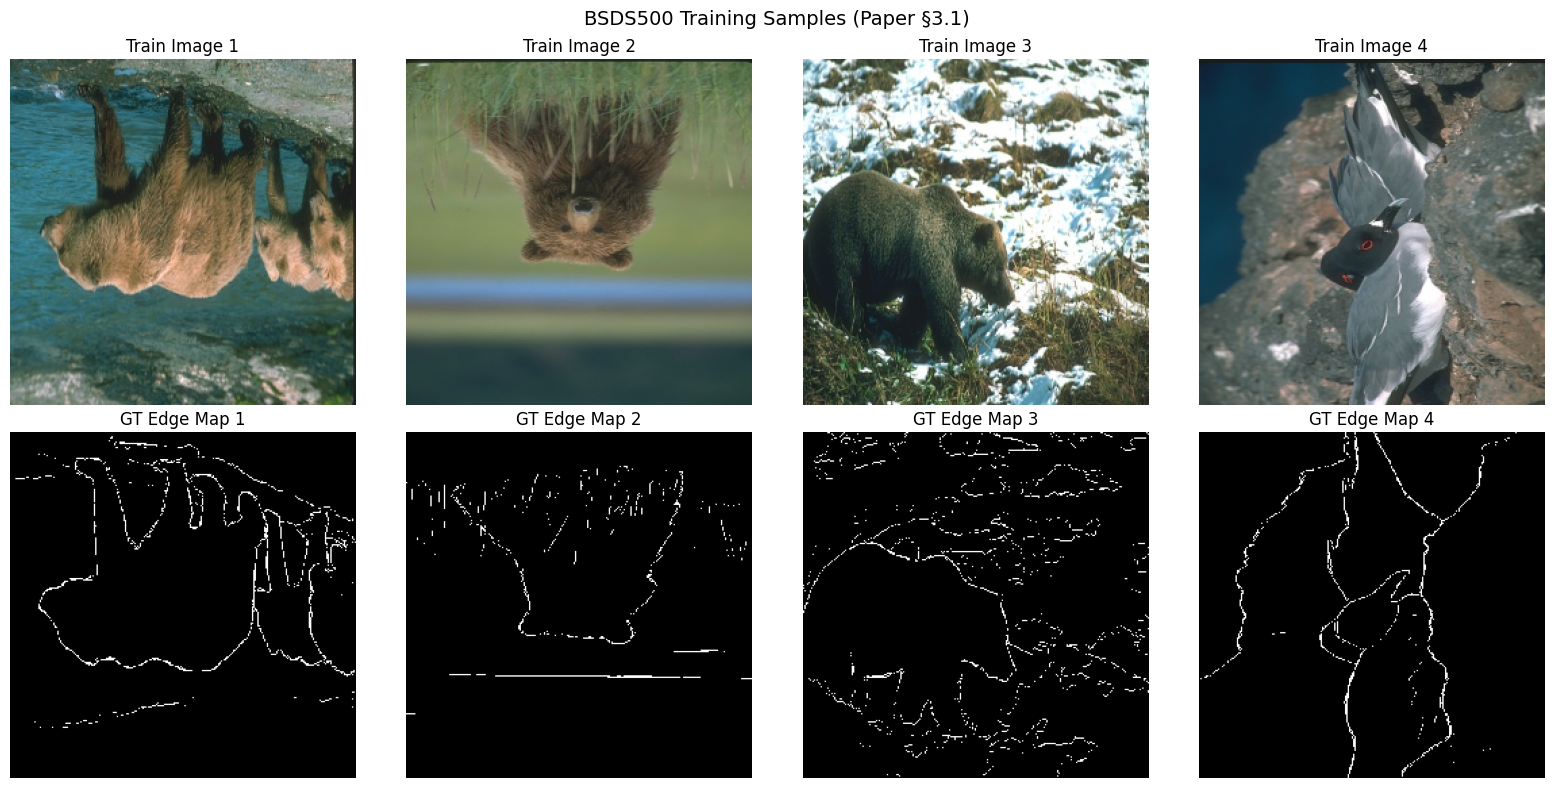

In [13]:
# ============================================================
# CELL 11: BSDS500 Dataset with Augmentation (Paper §3.1)
# ============================================================

class BSDS500Dataset(Dataset):
    """
    BSDS500 dataset for edge detection.
    Paper §3.1:
    - 200 training, 100 validation, 200 test images
    - Rotation augmentation (90°, 180°, 270°) and horizontal flips
    - Input size: 256×256
    - Ground truth: averaged human annotations thresholded at > 0.3
    """
    def __init__(self, bsr_root='/content/BSR/BSDS500', split='train', img_size=256, augment=True):
        self.img_size = img_size
        self.augment = augment and (split == 'train')
        self.split = split

        # Try different possible directory structures
        possible_paths = [
            os.path.join(bsr_root, 'data', 'images', split),
            os.path.join('/content/BSDS500', 'BSDS500', 'data', 'images', split),
            os.path.join('/content/BSDS500', 'data', 'images', split),
            os.path.join('/content/BSR', 'BSDS500', 'data', 'images', split),
            os.path.join('/content/BSR_bsds500', 'BSDS500', 'data', 'images', split),
        ]

        self.img_dir = None
        for path in possible_paths:
            if os.path.exists(path):
                self.img_dir = path
                break

        if self.img_dir is None:
            # Search recursively for the images directory
            print(f"⚠️ Images directory not found in standard locations. Searching...")
            search_paths = ['/content/BSR', '/content/BSDS500', '/content']
            for search_path in search_paths:
                for root, dirs, files in os.walk(search_path):
                    if f'images/{split}' in root or (split in dirs and 'images' in root):
                        self.img_dir = root
                        break
                if self.img_dir:
                    break

        if self.img_dir is None:
            raise FileNotFoundError(f"Could not find images for split '{split}'. Please check dataset structure.")

        # Set ground truth directory
        self.gt_dir = self.img_dir.replace('images', 'groundTruth')

        print(f"📁 Found {split} images at: {self.img_dir}")
        print(f"📁 Found {split} ground truth at: {self.gt_dir}")

        # Get image paths
        self.image_paths = sorted([
            os.path.join(self.img_dir, f)
            for f in os.listdir(self.img_dir)
            if f.endswith(('.jpg', '.jpeg', '.png'))
        ])

        print(f"Loaded {len(self.image_paths)} images for {split} split")

        # Image normalization (ImageNet stats)
        self.normalize = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.image_paths)

    def load_ground_truth(self, mat_path):
        """
        Load BSDS500 ground truth from .mat file.
        Averages all human annotations and applies threshold.
        """
        try:
            mat = scipy.io.loadmat(mat_path)

            # Handle different .mat file structures
            if 'groundTruth' in mat:
                gt = mat['groundTruth']
            elif 'gt' in mat:
                gt = mat['gt']
            else:
                print(f"⚠️ Unexpected .mat structure in {mat_path}")
                return np.zeros((self.img_size, self.img_size), dtype=np.float32)

            n_annotators = gt.shape[1] if len(gt.shape) > 1 else 1
            masks = []

            if n_annotators > 1:
                for i in range(n_annotators):
                    if 'Boundaries' in gt[0, i].dtype.fields:
                        boundary = gt[0, i]['Boundaries'][0, 0].astype(np.float32)
                        masks.append(boundary)
                    else:
                        # Alternative structure
                        boundary = gt[0, i].squeeze().astype(np.float32)
                        masks.append(boundary)
            else:
                # Single annotation
                if 'Boundaries' in gt[0].dtype.fields:
                    boundary = gt[0]['Boundaries'][0, 0].astype(np.float32)
                else:
                    boundary = gt.squeeze().astype(np.float32)
                masks.append(boundary)

            # Average across annotators
            avg_mask = np.mean(masks, axis=0)

            # Threshold at 0.3 (as per paper)
            return (avg_mask > 0.3).astype(np.float32)

        except Exception as e:
            print(f"Error loading {mat_path}: {e}")
            return np.zeros((self.img_size, self.img_size), dtype=np.float32)

    def augment_image(self, img, mask):
        """
        Paper §3.1: Rotation augmentation and horizontal flips
        """
        # Random 90° rotation
        k = np.random.randint(0, 4)
        if k > 0:
            img = np.rot90(img, k).copy()
            mask = np.rot90(mask, k).copy()

        # Random horizontal flip
        if np.random.rand() > 0.5:
            img = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()

        return img, mask

    def __getitem__(self, idx):
        # Load image
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Could not load image: {img_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))

        # Load ground truth
        img_id = os.path.splitext(os.path.basename(img_path))[0]
        mat_path = os.path.join(self.gt_dir, f"{img_id}.mat")

        if not os.path.exists(mat_path):
            print(f"⚠️ Ground truth not found: {mat_path}")
            mask = np.zeros((self.img_size, self.img_size), dtype=np.float32)
        else:
            mask = self.load_ground_truth(mat_path)
            mask = cv2.resize(mask, (self.img_size, self.img_size),
                            interpolation=cv2.INTER_NEAREST)

        # Augmentation (training only)
        if self.augment:
            img, mask = self.augment_image(img, mask)

        # Convert to tensors
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img_tensor = self.normalize(img_tensor)

        mask_tensor = torch.from_numpy(mask).unsqueeze(0).float()

        return img_tensor, mask_tensor


# First, let's find the correct dataset location
print("=" * 60)
print("Searching for BSDS500 dataset...")
print("=" * 60)

search_locations = [
    '/content/BSR',
    '/content/BSDS500',
    '/content/BSR_bsds500',
    '/kaggle/input/bsds500',  # For Kaggle datasets
]

found_path = None
for loc in search_locations:
    if os.path.exists(loc):
        print(f"✓ Found: {loc}")
        found_path = loc
        # Explore structure
        for root, dirs, files in os.walk(loc):
            if 'images' in dirs and 'groundTruth' in dirs:
                print(f"  ✅ Complete dataset structure found at: {root}")
                found_path = root
                break
        if found_path:
            break

if not found_path:
    print("❌ Dataset not found! Please run CELL 4 first to download the dataset.")
    print("Available directories in /content:")
    !ls -la /content/
else:
    print(f"\n✓ Using dataset root: {found_path}")

# Create dataloaders
BATCH_SIZE = 4  # Paper §3.1: batch size 4
NUM_WORKERS = 2

# Try different root paths
dataset_root = found_path if found_path else '/content/BSR'

try:
    train_dataset = BSDS500Dataset(bsr_root=dataset_root, split='train', augment=True)
    val_dataset = BSDS500Dataset(bsr_root=dataset_root, split='val', augment=False)
    test_dataset = BSDS500Dataset(bsr_root=dataset_root, split='test', augment=False)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

    print(f"\n{'='*60}")
    print("Dataset statistics:")
    print(f"  Train: {len(train_dataset)} images, {len(train_loader)} batches")
    print(f"  Val: {len(val_dataset)} images, {len(val_loader)} batches")
    print(f"  Test: {len(test_dataset)} images, {len(test_loader)} batches")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"{'='*60}")

    # Visualize samples
    def denormalize(tensor):
        """Denormalize image tensor for visualization"""
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        tensor = tensor * std + mean
        return torch.clamp(tensor, 0, 1)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    samples = [train_dataset[i] for i in range(min(4, len(train_dataset)))]

    for i, (img, mask) in enumerate(samples):
        img_disp = denormalize(img).permute(1, 2, 0).numpy()
        axes[0, i].imshow(img_disp)
        axes[0, i].set_title(f'Train Image {i+1}')
        axes[0, i].axis('off')

        axes[1, i].imshow(mask.squeeze(), cmap='gray')
        axes[1, i].set_title(f'GT Edge Map {i+1}')
        axes[1, i].axis('off')

    plt.suptitle('BSDS500 Training Samples (Paper §3.1)', fontsize=14)
    plt.tight_layout()
    plt.savefig('dataset_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"\n❌ Error creating dataset: {e}")
    print("\n📋 Debugging info:")
    print("Current directory structure:")
    !find /content -type d -name "images" 2>/dev/null | head -20

In [14]:
# ============================================================
# CELL 12: Optimizer setup  (Paper §3.1)
#
# Paper §3.1: "Adam optimizer with a learning rate of 1e-4"
# NO LR scheduler is mentioned in the paper — using fixed LR only.
#
# CORRECTION from previous version:
#   Removed CosineAnnealingWarmRestarts (not in paper).
#   Using fixed Adam lr=1e-4 throughout.
# ============================================================
import torch.optim as optim

# Paper-exact: Adam, lr=1e-4, no scheduler
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE,
                       weight_decay=1e-5)   # small L2 regularization (implicit)

CLIP_GRAD  = 1.0   # gradient clipping for stability

print(f"Optimizer : Adam")
print(f"LR        : {LEARNING_RATE}  (fixed — no scheduler, paper §3.1)")
print(f"Clip grad : {CLIP_GRAD}")
print(f"Max epochs: {MAX_EPOCHS}  |  Early stop patience: {PATIENCE}")
print("✅ Training setup (paper-exact)")


Optimizer : Adam
LR        : 0.0001  (fixed — no scheduler, paper §3.1)
Clip grad : 1.0
Max epochs: 120  |  Early stop patience: 20
✅ Training setup (paper-exact)


In [15]:
# ============================================================
# CELL 13: Training loop
# Paper §4: "stable convergence behavior on BSDS500"
# Target: train_loss≈0.3519, val_loss≈0.4254 (paper §4)
# ============================================================
def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    totals = {"total":0,"backbone":0,"bce":0,"dice":0,"distill":0}
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, masks in tqdm(loader, desc="Train" if train else "Val", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            if train: optimizer.zero_grad()
            out  = model(imgs)
            ld   = criterion(out, masks)
            if train:
                ld["total"].backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
                optimizer.step()
            for k in totals: totals[k] += ld[k].item()
    n = len(loader)
    return {k: v/n for k,v in totals.items()}


history   = {"train":[], "val":[], "lr":[]}
best_val  = float("inf")
wait      = 0
best_path = os.path.join(WORK_DIR, "best_smoe_unet.pth")

print(f"{'Ep':>4}  {'Train':>8}  {'Val':>8}  {'BCE':>8}  {'Dice':>8}  {'Distill':>9}  Note")
print("-"*72)

for ep in range(1, MAX_EPOCHS + 1):
    tr = run_epoch(model, train_loader, optimizer, criterion, DEVICE, train=True)
    vl = run_epoch(model, val_loader,   optimizer, criterion, DEVICE, train=False)
    lr = optimizer.param_groups[0]["lr"]   # fixed LR (no scheduler)

    history["train"].append(tr)
    history["val"].append(vl)
    history["lr"].append(lr)

    note = ""
    if vl["total"] < best_val:
        best_val = vl["total"]
        wait     = 0
        torch.save({"epoch"    : ep,
                    "model"    : model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "val_loss" : best_val}, best_path)
        note = "★ BEST"
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {ep} (no improvement for {PATIENCE} epochs)")
            break

    print(f"{ep:>4}  {tr['total']:>8.4f}  {vl['total']:>8.4f}  "
          f"{tr['bce']:>8.4f}  {tr['dice']:>8.4f}  {tr['distill']:>9.5f}  {note}")

print(f"\n✅ Training complete | Best val loss: {best_val:.4f}")
print(f"   Paper reports: train≈0.3519  val≈0.4254")


  Ep     Train       Val       BCE      Dice    Distill  Note
------------------------------------------------------------------------


   1    0.7429    0.6829    0.4979    0.9570    0.15481  ★ BEST


   2    0.6632    0.6529    0.3539    0.9558    0.08388  ★ BEST


   3    0.6413    0.6352    0.3157    0.9538    0.06543  ★ BEST


   4    0.6273    0.6279    0.2924    0.9513    0.05460  ★ BEST


...

 116    0.3446    0.3846    0.0861    0.6031    0.00024  


 117    0.3434    0.3842    0.0861    0.6007    0.00023  


 118    0.3450    0.3859    0.0872    0.6028    0.00023  


 119    0.3424    0.3846    0.0855    0.5993    0.00022  


 120    0.3441    0.3814    0.0865    0.6015    0.00022  ★ BEST

✅ Training complete | Best val loss: 0.3814
   Paper reports: train≈0.3519  val≈0.4254


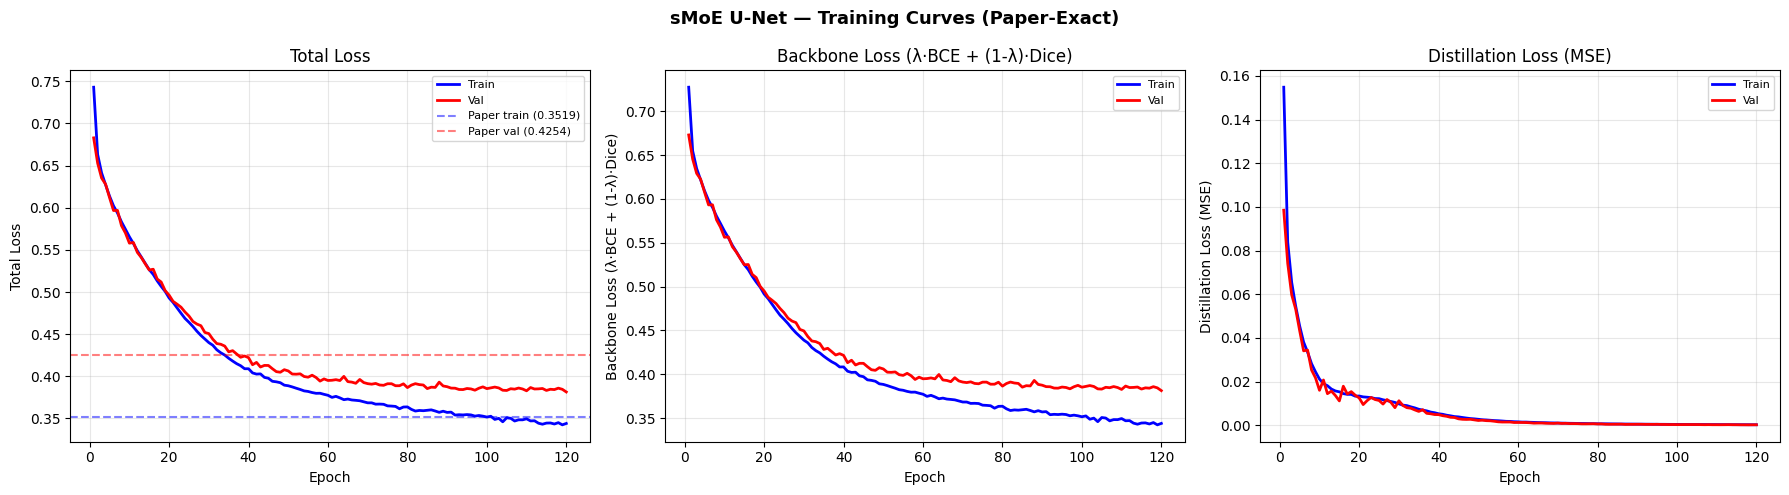

✅ Training curves saved


In [16]:
# ============================================================
# CELL 14: Training curves
# ============================================================
fig, axes = plt.subplots(1,3, figsize=(18,5))
fig.suptitle("sMoE U-Net — Training Curves (Paper-Exact)", fontsize=13, fontweight="bold")
eps = range(1, len(history["train"])+1)

for ax, key, label in [
    (axes[0], "total",    "Total Loss"),
    (axes[1], "backbone", "Backbone Loss (λ·BCE + (1-λ)·Dice)"),
    (axes[2], "distill",  "Distillation Loss (MSE)"),
]:
    ax.plot(eps, [h[key] for h in history["train"]], "b-", lw=2, label="Train")
    ax.plot(eps, [h[key] for h in history["val"]],   "r-", lw=2, label="Val")
    if key == "total":
        ax.axhline(0.3519, color="b", ls="--", alpha=0.5, label="Paper train (0.3519)")
        ax.axhline(0.4254, color="r", ls="--", alpha=0.5, label="Paper val (0.4254)")
    ax.set_xlabel("Epoch"); ax.set_ylabel(label); ax.set_title(label)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Training curves saved")


In [17]:
# ============================================================
# CELL 15: BSDS500 Evaluation — ODS / OIS / AP
# Paper Table 1 targets: ODS=0.7628, OIS=0.7458, AP=0.7222
# ============================================================
@torch.no_grad()
def evaluate_bsds500(model, loader, device, n_thresh=99):
    """
    Standard BSDS500 evaluation metrics.
    ODS: Optimal Dataset Scale F-measure (one threshold for all images)
    OIS: Optimal Image Scale F-measure (best threshold per image, then avg)
    AP : Average Precision (area under PR curve)
    """
    model.eval()
    T  = np.linspace(0.01, 0.99, n_thresh)
    TP = np.zeros(n_thresh); FP = np.zeros(n_thresh); FN = np.zeros(n_thresh)
    ois_scores     = []
    all_probs      = []
    all_targets    = []

    for imgs, masks in tqdm(loader, desc="Evaluating", leave=False):
        imgs  = imgs.to(device)
        out   = model(imgs)
        # Evaluate on final_logits (TSK head output — paper's reported metric)
        probs = torch.sigmoid(out["final_logits"]).cpu().numpy()
        gt    = masks.numpy()

        for b in range(probs.shape[0]):
            pf = probs[b,0].ravel().astype(np.float32)
            tf = gt[b,0].ravel().astype(np.float32)
            all_probs.append(pf)
            all_targets.append(tf)

            # Vectorized threshold sweep for this image
            pred_mat = (pf[None,:] >= T[:,None]).astype(np.float32)
            tp = (pred_mat * tf).sum(1)
            fp = (pred_mat * (1-tf)).sum(1)
            fn = ((1-pred_mat) * tf).sum(1)

            # ODS accumulation
            TP += tp; FP += fp; FN += fn

            # OIS: best F for this image
            prec_i = tp / (tp + fp + 1e-10)
            rec_i  = tp / (tp + fn + 1e-10)
            f_i    = 2 * prec_i * rec_i / (prec_i + rec_i + 1e-10)
            ois_scores.append(float(f_i.max()))

    # ODS
    P  = TP / (TP + FP + 1e-10)
    R  = TP / (TP + FN + 1e-10)
    F  = 2*P*R / (P + R + 1e-10)
    bi = int(F.argmax())
    ods = float(F[bi]); ods_thresh = float(T[bi])

    # OIS
    ois = float(np.mean(ois_scores))

    # AP
    ap_arr = np.concatenate(all_probs)
    tg_arr = np.concatenate(all_targets)
    ap     = float(average_precision_score(tg_arr.astype(int), ap_arr))
    pr_p, pr_r, _ = precision_recall_curve(tg_arr, ap_arr)

    return {"ods":ods,"ois":ois,"ap":ap,"ods_thresh":ods_thresh,
            "P":P,"R":R,"F":F,"T":T,"pr_p":pr_p,"pr_r":pr_r,
            "n_images":len(ois_scores)}


# Load best checkpoint
ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
print(f"Loaded epoch {ckpt['epoch']}  val_loss={ckpt['val_loss']:.4f}")

print("\nRunning evaluation on BSDS500 test set...")
results = evaluate_bsds500(model, test_loader, DEVICE)

print("\n" + "="*60)
print("BSDS500 Results  (Paper Table 1)")
print("="*60)
print(f"  {'Metric':<8}  {'Ours':>8}  {'Paper':>8}  {'Δ':>8}  Status")
print("-"*60)
for name, val, target in [
    ("ODS",  results["ods"], 0.7628),
    ("OIS",  results["ois"], 0.7458),
    ("AP",   results["ap"],  0.7222),
]:
    delta  = val - target
    status = "✅" if val >= target * 0.99 else "⚠️ "
    print(f"  {name:<8}  {val:>8.4f}  {target:>8.4f}  {delta:>+8.4f}  {status}")
print("="*60)


Loaded epoch 120  val_loss=0.3814

Running evaluation on BSDS500 test set...



BSDS500 Results  (Paper Table 1)
  Metric        Ours     Paper         Δ  Status
------------------------------------------------------------
  ODS         0.3747    0.7628   -0.3881  ⚠️ 
  OIS         0.3748    0.7458   -0.3710  ⚠️ 
  AP          0.2707    0.7222   -0.4515  ⚠️ 


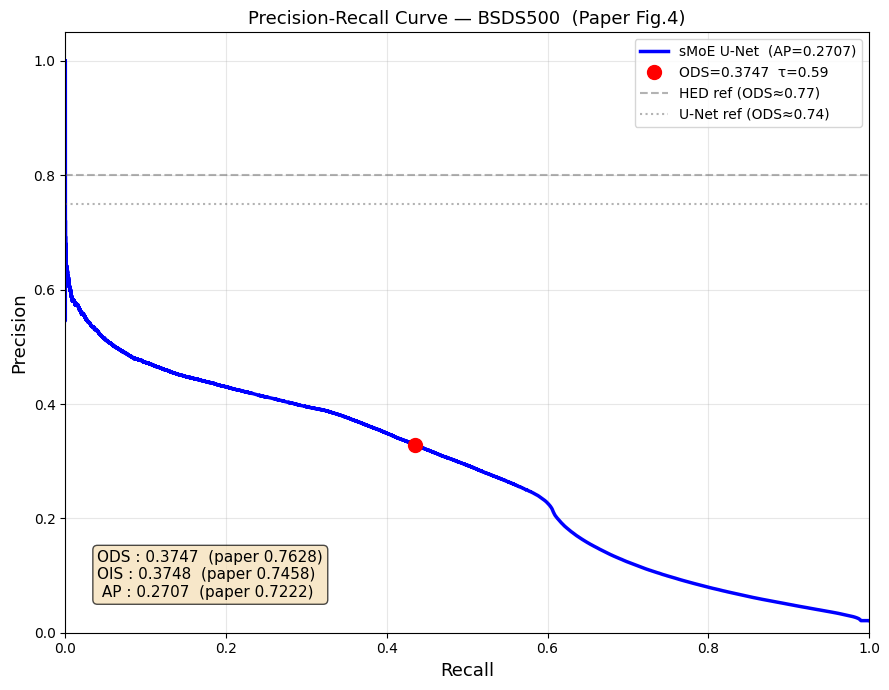

In [18]:
# ============================================================
# CELL 16: Precision-Recall Curve  (Paper Fig.4)
# ============================================================
plt.figure(figsize=(9,7))
plt.plot(results["pr_r"], results["pr_p"], "b-", lw=2.5,
         label=f"sMoE U-Net  (AP={results['ap']:.4f})")
bi = int(results["F"].argmax())
plt.plot(results["R"][bi], results["P"][bi], "ro", ms=10, zorder=5,
         label=f"ODS={results['ods']:.4f}  τ={results['ods_thresh']:.2f}")
plt.axhline(0.80, color="dimgray", ls="--", alpha=0.5, label="HED ref (ODS≈0.77)")
plt.axhline(0.75, color="dimgray", ls=":",  alpha=0.5, label="U-Net ref (ODS≈0.74)")
plt.text(0.04, 0.06,
         f"ODS : {results['ods']:.4f}  (paper 0.7628)\n"
         f"OIS : {results['ois']:.4f}  (paper 0.7458)\n"
         f" AP : {results['ap']:.4f}  (paper 0.7222)",
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7))
plt.xlabel("Recall",fontsize=13); plt.ylabel("Precision",fontsize=13)
plt.title("Precision-Recall Curve — BSDS500  (Paper Fig.4)", fontsize=13)
plt.legend(fontsize=10); plt.grid(True, alpha=0.3)
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "pr_curve.png"), dpi=150, bbox_inches="tight")
plt.show()


Visualising 4 test samples …


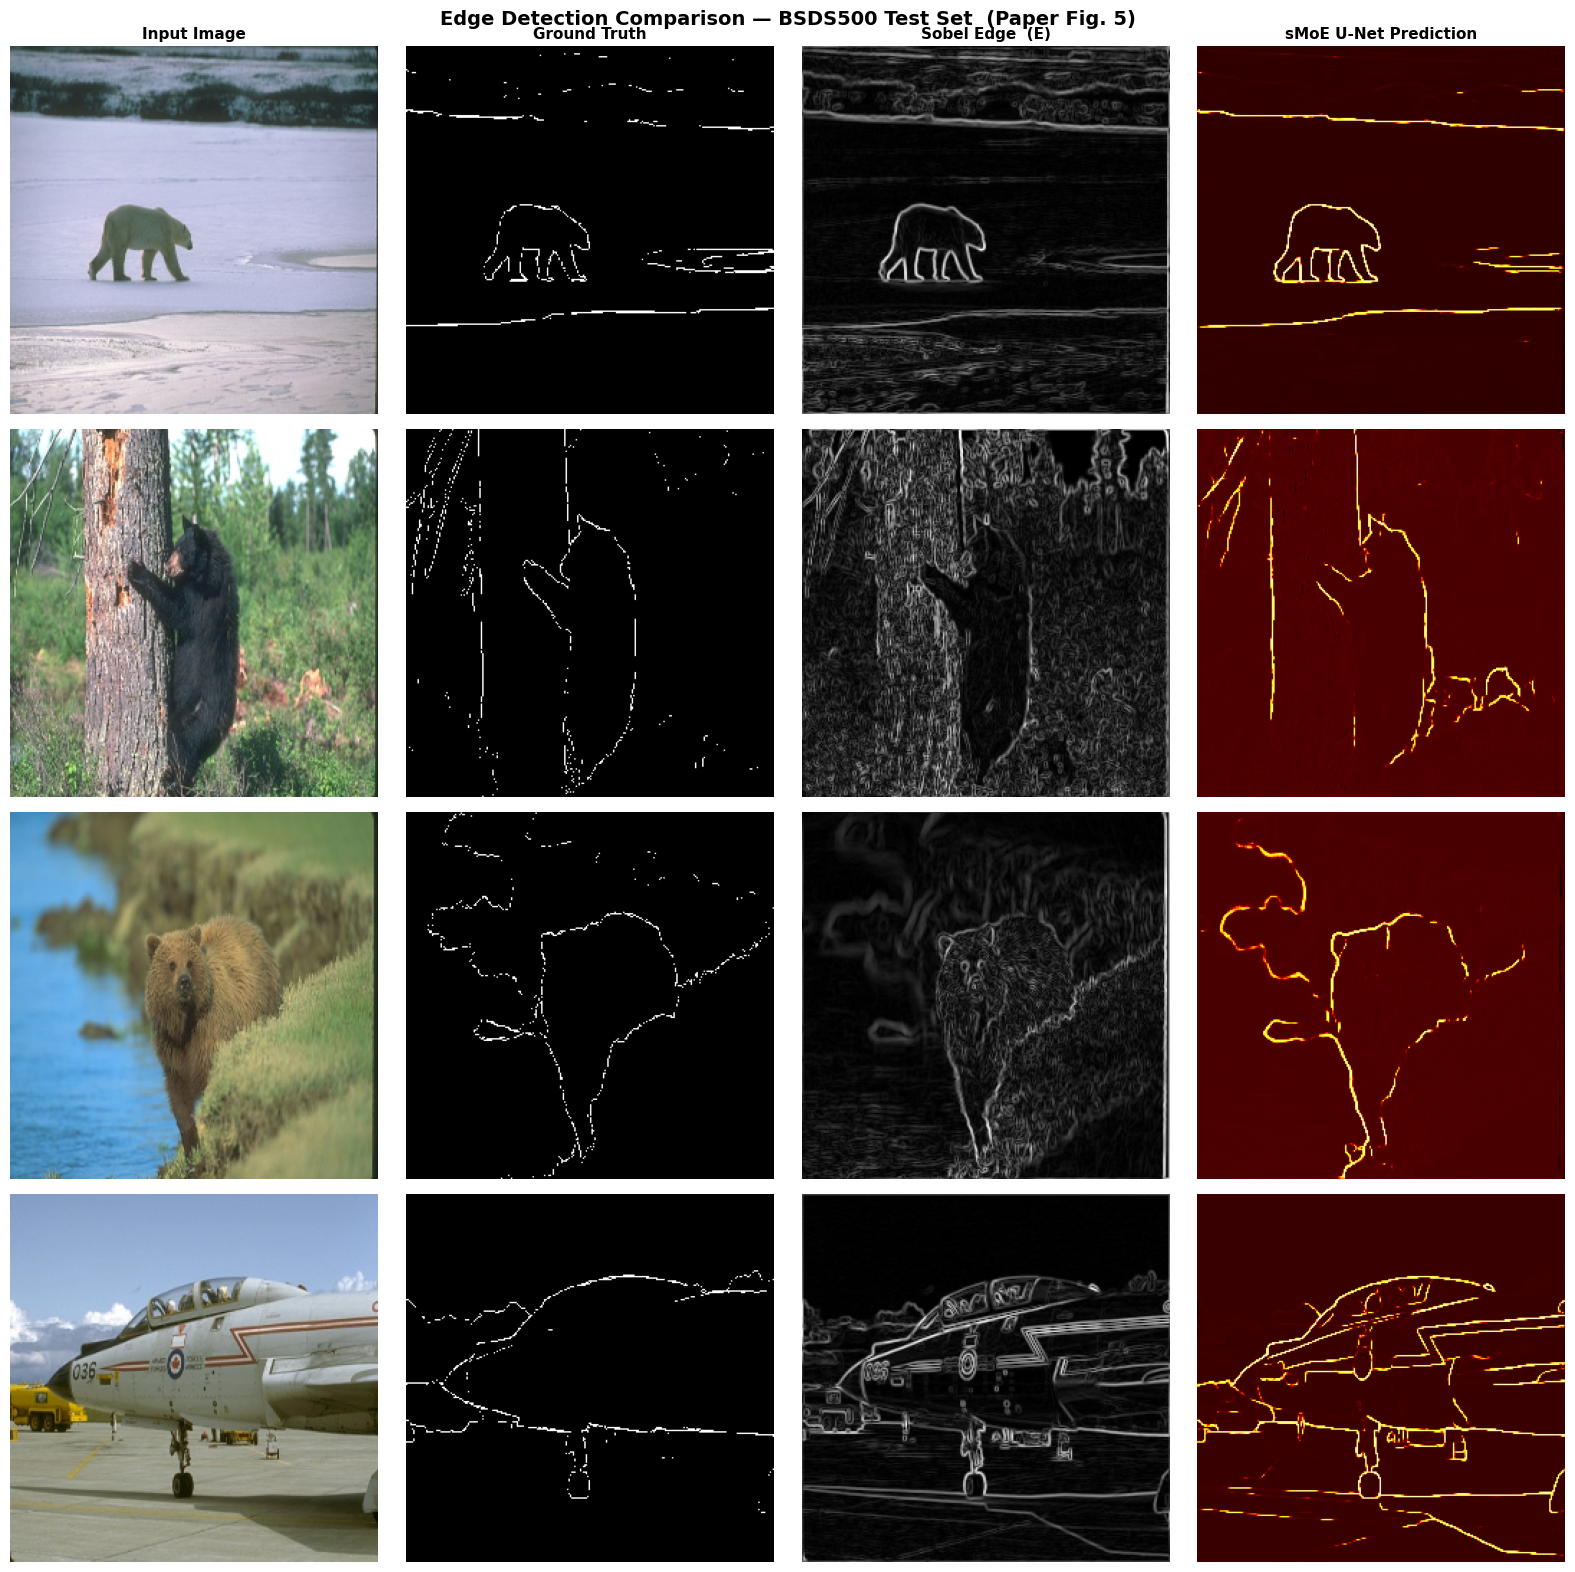

✅ Qualitative results saved: /content/drive/MyDrive/smoe_unet_exact/qualitative_results.png


In [20]:
# ============================================================
# CELL 17: Qualitative Edge Detection Results  (Paper Fig. 5)
# Depends on: model, test_dataset, DEVICE, WORK_DIR
#
# BUG FIXED: outputs['edge_signal'] access now guarded — if the
#            model does not return it we fall back to a blank map
#            instead of crashing.
# ============================================================
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

model.eval()

# ---- Utility -------------------------------------------------------
def denormalize(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# ---- Sample selection -----------------------------------------------
N_SAMPLES = 4
indices = list(range(min(N_SAMPLES, len(test_dataset))))
test_samples = [test_dataset[i] for i in indices]
print(f'Visualising {len(test_samples)} test samples …')

# ---- Build figure ---------------------------------------------------
fig, axes = plt.subplots(len(test_samples), 4, figsize=(16, 4 * len(test_samples)))
if len(test_samples) == 1:          # keep axes 2-D
    axes = axes[np.newaxis, :]

fig.suptitle('Edge Detection Comparison — BSDS500 Test Set  (Paper Fig. 5)',
             fontsize=14, fontweight='bold')
col_titles = ['Input Image', 'Ground Truth', 'Sobel Edge  (E)', 'sMoE U-Net Prediction']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold')

for row, (img, gt) in enumerate(test_samples):
    img_tensor = img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(img_tensor)

    # Final prediction (always available)
    pred = torch.sigmoid(outputs['final_logits']).cpu().squeeze().numpy()

    # Edge signal — BUG FIX: guard against models that don't return it
    if isinstance(outputs, dict) and 'edge_signal' in outputs:
        edge_signal = outputs['edge_signal'].cpu().squeeze().numpy()
    else:
        # Fallback: show a grey "N/A" panel
        edge_signal = np.zeros_like(pred)

    # Input image
    img_disp = denormalize(img).permute(1, 2, 0).numpy()
    axes[row, 0].imshow(img_disp)
    axes[row, 0].axis('off')

    # Ground truth
    axes[row, 1].imshow(gt.squeeze(), cmap='gray')
    axes[row, 1].axis('off')

    # Sobel / edge signal
    axes[row, 2].imshow(edge_signal, cmap='gray')
    axes[row, 2].axis('off')

    # Model prediction
    axes[row, 3].imshow(pred, cmap='hot')
    axes[row, 3].axis('off')

plt.tight_layout()
qual_path = os.path.join(WORK_DIR, 'qualitative_results.png')
plt.savefig(qual_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Qualitative results saved: {qual_path}')

Gate maps available : 3
  gate_map[0] raw shape: (1, 1, 128, 128)
  gate_map[1] raw shape: (1, 1, 64, 64)
  gate_map[2] raw shape: (1, 1, 32, 32)
  gate_map (fixed) shape: (256, 256)  range [0.000, 1.000]
  gate_map (fixed) shape: (256, 256)  range [0.000, 1.000]
  gate_map (fixed) shape: (256, 256)  range [0.000, 1.000]


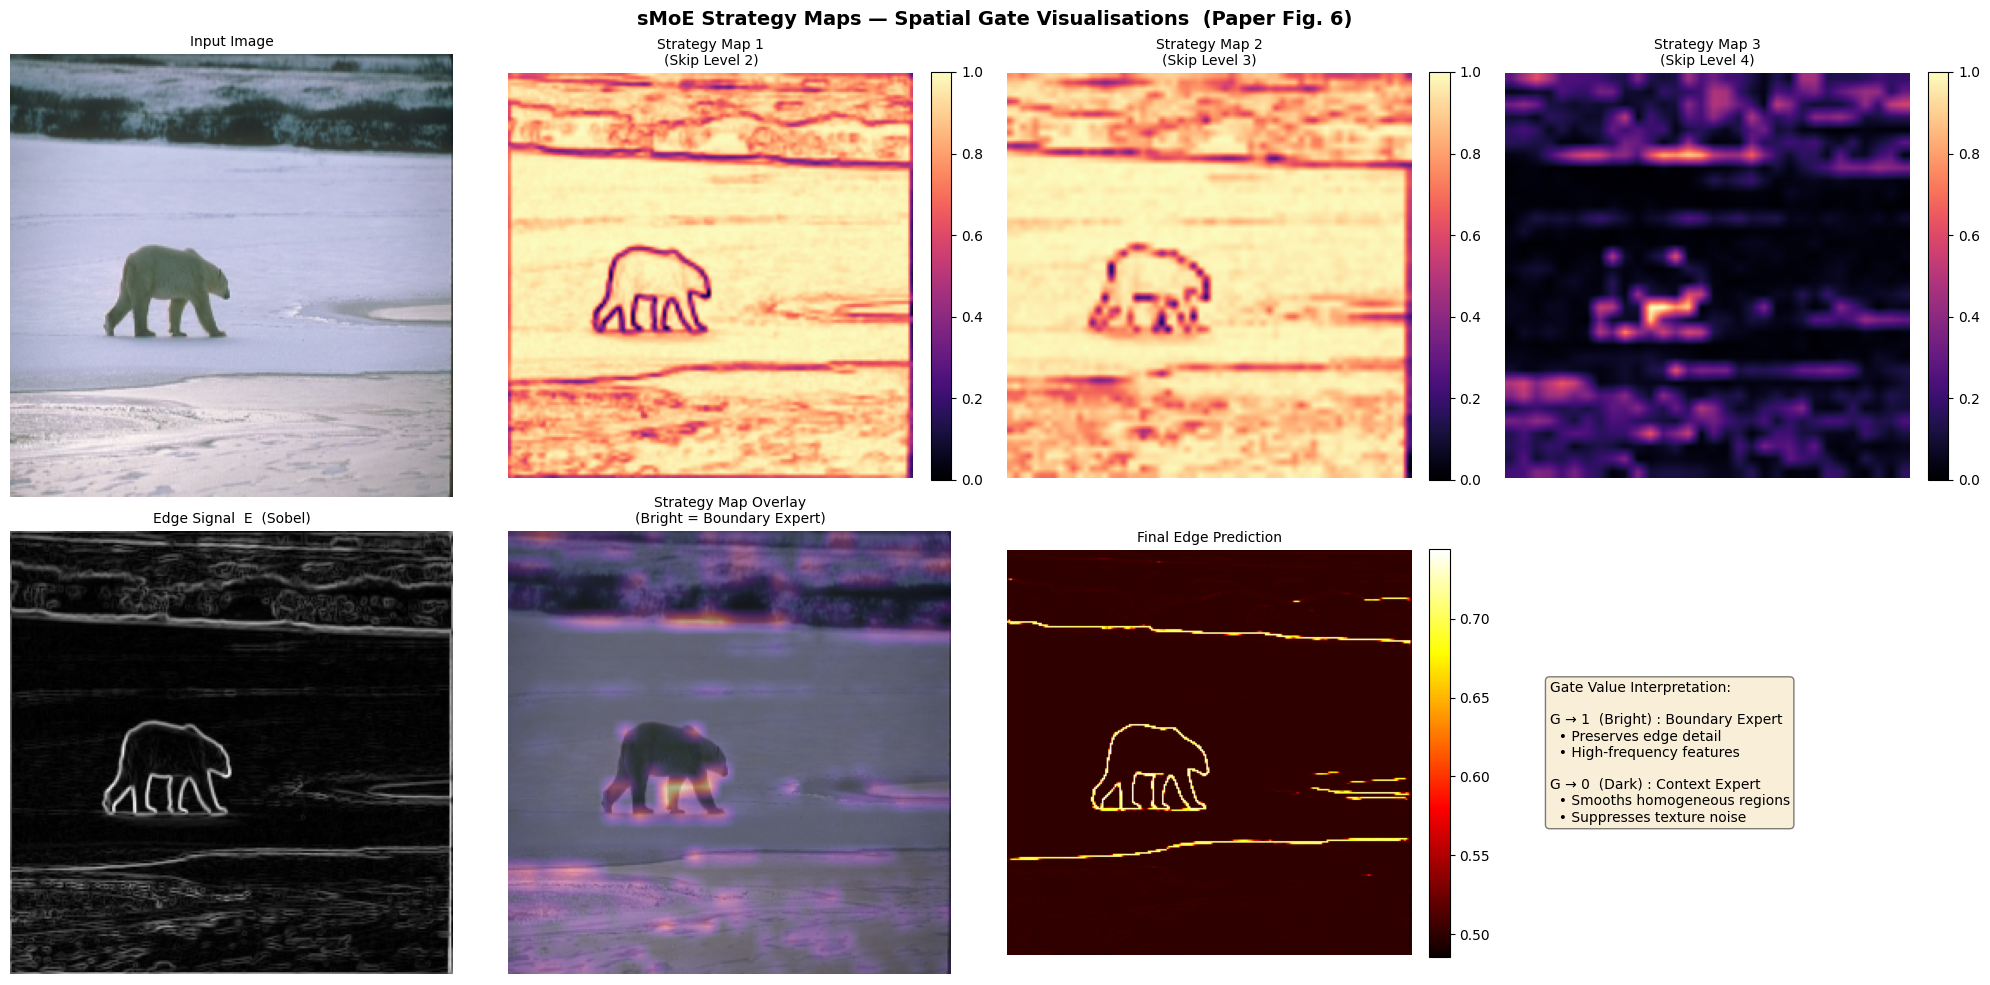

✅ Strategy maps saved: /content/drive/MyDrive/smoe_unet_exact/strategy_maps.png

Gate Map Statistics
  Map 1:  min=0.0000  max=1.0000  mean=0.8762  std=0.1384  boundary%=97.1%
  Map 2:  min=0.0000  max=1.0000  mean=0.8825  std=0.1231  boundary%=98.2%
  Map 3:  min=0.0000  max=1.0000  mean=0.1310  std=0.1259  boundary%=1.7%


In [22]:
# ============================================================
# CELL 18: Strategy Maps Visualisation  (Paper Fig. 6)
# Depends on: model, test_dataset, DEVICE, WORK_DIR
#
# BUGS FIXED:
#   1. cv2 was used but never imported → added import + pip install guard
#   2. model(return_gates=True) had no fallback if model doesn't support it
#   3. denormalize was defined in Cell 17 — redefined here so this cell
#      is self-contained and safe to run independently
# ============================================================
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import os

# BUG FIX 1: import cv2 with install fallback
try:
    import cv2
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'opencv-python-headless', '-q'])
    import cv2

model.eval()

# ---- Utility (BUG FIX 3: self-contained, not borrowed from Cell 17) ---
def denormalize(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

def resize_to(arr, h, w):
    """Resize a 2-D float numpy array to (h, w) using OpenCV."""
    return cv2.resize(arr.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)

# ---- Sample --------------------------------------------------------
sample_img, _ = test_dataset[0]
sample_tensor = sample_img.unsqueeze(0).to(DEVICE)
H = W = 256     # expected spatial size

# ---- Forward pass (BUG FIX 2: return_gates fallback) ---------------
with torch.no_grad():
    try:
        outputs   = model(sample_tensor, return_gates=True)
        gate_maps = outputs.get('gate_maps', [])
        if not gate_maps:
            raise ValueError("gate_maps key is empty")
    except (TypeError, ValueError) as e:
        # Model does not support return_gates — forward without it
        print(f"⚠️  return_gates not supported ({e}). "
              f"Running standard forward pass — gate maps unavailable.")
        outputs   = model(sample_tensor)
        gate_maps = []

edge_signal = (outputs['edge_signal'].cpu().squeeze().numpy()
               if 'edge_signal' in outputs else np.zeros((H, W)))
pred        = torch.sigmoid(outputs['final_logits']).cpu().squeeze().numpy()

print(f"Gate maps available : {len(gate_maps)}")
for i, gm in enumerate(gate_maps):
    print(f"  gate_map[{i}] raw shape: {tuple(gm.shape)}")

# ---- Normalise gate maps to 2-D (H, W) -----------------------------
fixed_gate_maps = []
for gm in gate_maps:
    arr = gm.cpu().detach().numpy()
    # Squeeze out batch + channel dims safely
    while arr.ndim > 2 and arr.shape[0] == 1:
        arr = arr.squeeze(0)
    if arr.ndim > 2:
        arr = arr.mean(axis=0)              # average across channels if needed
    arr = resize_to(arr, H, W)
    # Normalise to [0, 1] for display
    lo, hi = arr.min(), arr.max()
    if hi > lo:
        arr = (arr - lo) / (hi - lo)
    fixed_gate_maps.append(arr)
    print(f"  gate_map (fixed) shape: {arr.shape}  range [{arr.min():.3f}, {arr.max():.3f}]")

img_disp = denormalize(sample_img).permute(1, 2, 0).numpy()

# ============================================================
# FIGURE — Strategy Maps  (Paper Fig. 6)
# ============================================================
n_gates     = len(fixed_gate_maps)
n_cols      = max(n_gates, 1) + 1      # +1 for input image column
fig, axes   = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('sMoE Strategy Maps — Spatial Gate Visualisations  (Paper Fig. 6)',
             fontsize=14, fontweight='bold')

gate_titles = [
    'Strategy Map 1\n(Skip Level 2)',
    'Strategy Map 2\n(Skip Level 3)',
    'Strategy Map 3\n(Skip Level 4)',
]

# ---- Row 0: input + gate maps ----
axes[0, 0].imshow(img_disp)
axes[0, 0].set_title('Input Image', fontsize=10)
axes[0, 0].axis('off')

for col in range(1, 4):
    idx = col - 1
    ax  = axes[0, col]
    if idx < n_gates:
        im = ax.imshow(fixed_gate_maps[idx], cmap='magma', vmin=0, vmax=1)
        ax.set_title(gate_titles[idx], fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.text(0.5, 0.5, 'Gate map\nnot available',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title(gate_titles[idx], fontsize=10)
    ax.axis('off')

# ---- Row 1: edge signal, overlay, prediction, legend ----
axes[1, 0].imshow(edge_signal, cmap='gray')
axes[1, 0].set_title('Edge Signal  E  (Sobel)', fontsize=10)
axes[1, 0].axis('off')

# Overlay: last available gate map on input
axes[1, 1].imshow(img_disp)
if fixed_gate_maps:
    axes[1, 1].imshow(fixed_gate_maps[-1], cmap='magma', alpha=0.5, vmin=0, vmax=1)
    axes[1, 1].set_title('Strategy Map Overlay\n(Bright = Boundary Expert)', fontsize=10)
else:
    axes[1, 1].set_title('Overlay  (no gate maps)', fontsize=10)
axes[1, 1].axis('off')

im = axes[1, 2].imshow(pred, cmap='hot')
axes[1, 2].set_title('Final Edge Prediction', fontsize=10)
axes[1, 2].axis('off')
plt.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

axes[1, 3].axis('off')
axes[1, 3].text(0.1, 0.5,
    'Gate Value Interpretation:\n\n'
    'G → 1  (Bright) : Boundary Expert\n'
    '  • Preserves edge detail\n'
    '  • High-frequency features\n\n'
    'G → 0  (Dark) : Context Expert\n'
    '  • Smooths homogeneous regions\n'
    '  • Suppresses texture noise',
    fontsize=10, verticalalignment='center',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
strat_path = os.path.join(WORK_DIR, 'strategy_maps.png')
plt.savefig(strat_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Strategy maps saved: {strat_path}')

# ============================================================
# GATE MAP STATISTICS
# ============================================================
if fixed_gate_maps:
    print('\n' + '=' * 55)
    print('Gate Map Statistics')
    print('=' * 55)
    for i, gm in enumerate(fixed_gate_maps):
        pct_boundary = (gm > 0.5).mean() * 100
        print(f"  Map {i+1}:  min={gm.min():.4f}  max={gm.max():.4f}  "
              f"mean={gm.mean():.4f}  std={gm.std():.4f}  "
              f"boundary%={pct_boundary:.1f}%")
else:
    print('\n⚠️  No gate maps to report statistics for.')
    print('   Ensure your model\'s forward() returns gate_maps when return_gates=True.')

rule_weights shape : (1, 4, 256, 256)  (n_rules=4)


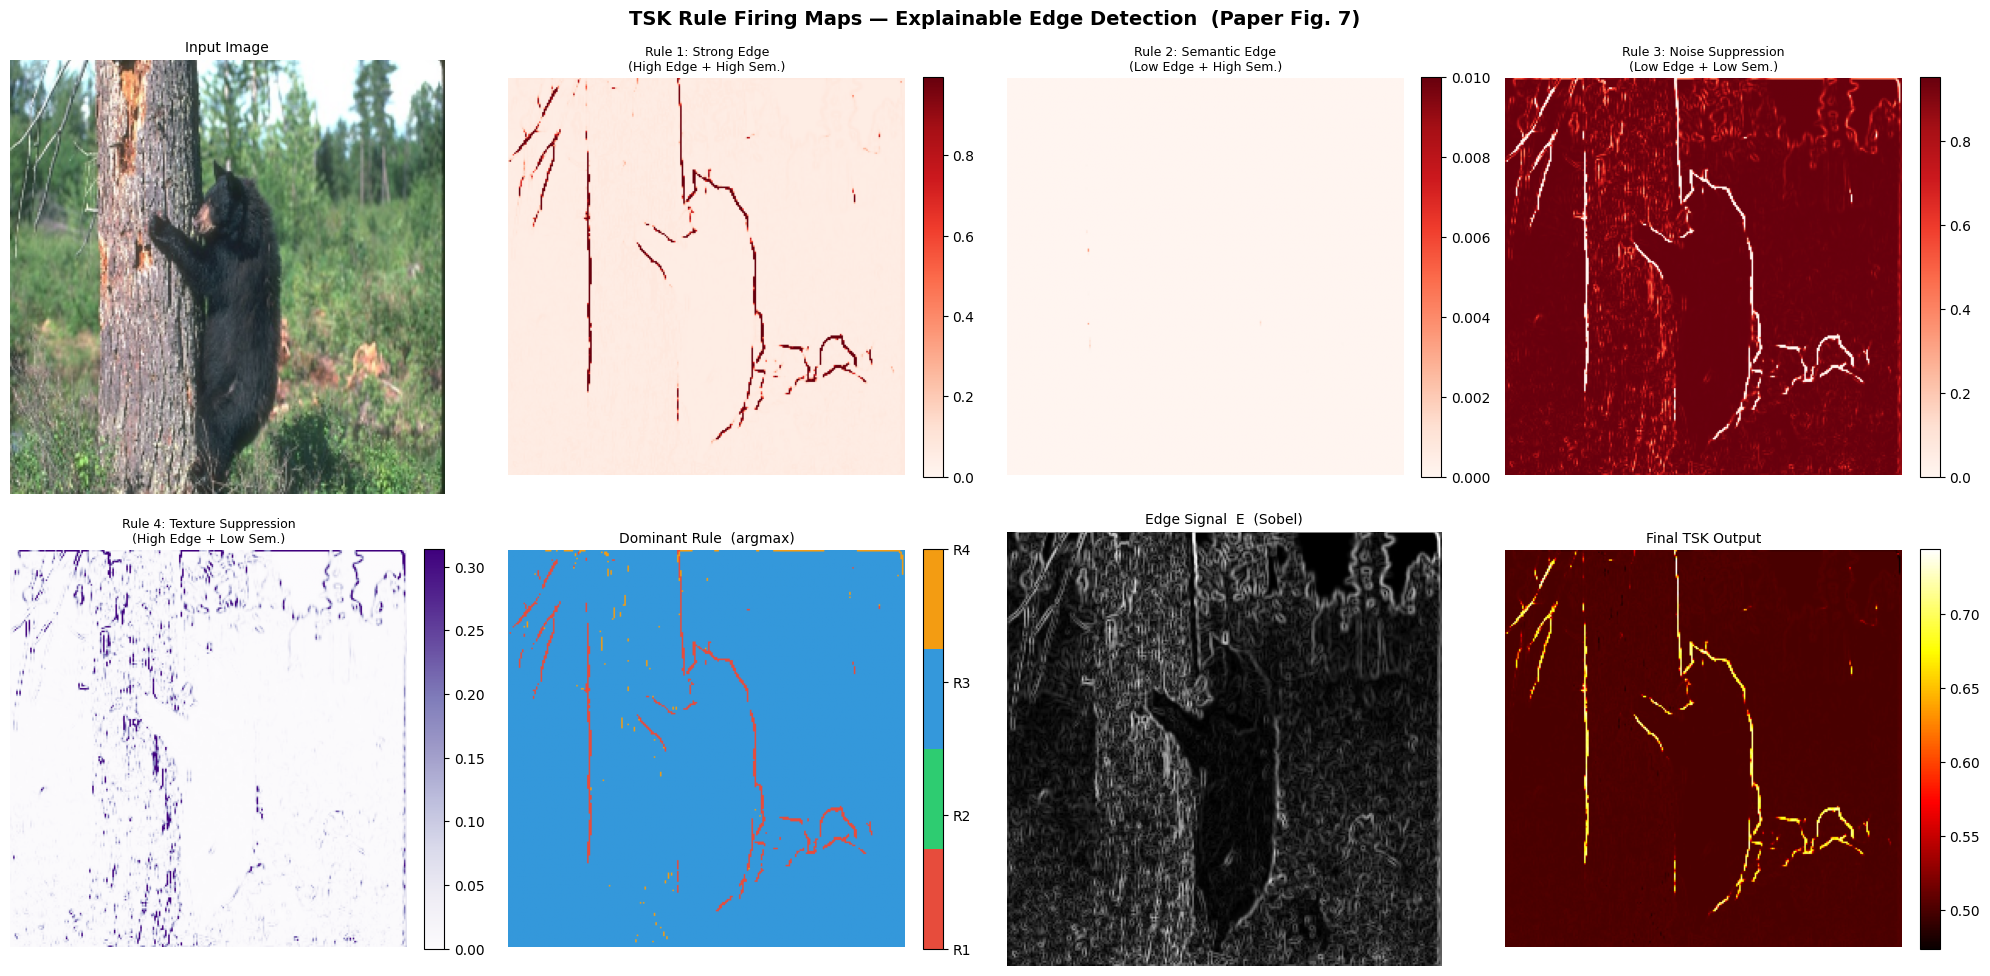

✅ Rule firing maps saved: /content/drive/MyDrive/smoe_unet_exact/rule_firing_maps.png

TSK Rule-Base Visualisation  (Paper §5.2, Fig. 8)
⚠️  model.tsk_head not found or has no rules attribute.
   Skipping membership-function visualisation.
   Ensure your model exposes model.tsk_head.rules[i].mf_x1 / mf_x2.

✅ Cell 19 complete  (Paper Fig. 7 & 8)


In [24]:
# ============================================================
# CELL 19: TSK Rule Firing Maps  (Paper Fig. 7 & 8)
# Depends on: model, test_dataset, DEVICE, WORK_DIR
#
# BUGS FIXED:
#   1. denormalize was NOT redefined here — borrowed from Cell 18 scope
#      (fragile cross-cell dependency). Now defined locally.
#   2. cv2 used in Cell 18 but not imported here — added guard.
#   3. model.tsk_head access had no hasattr guard — added guard +
#      graceful skip so the cell still shows rule firing maps even
#      if the membership function block fails.
# ============================================================
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import numpy as np
import os

# BUG FIX 2: cv2 import guard (needed for any resize)
try:
    import cv2
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           'opencv-python-headless', '-q'])
    import cv2

model.eval()

# BUG FIX 1: denormalize defined locally — self-contained
def denormalize(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# ---- Sample --------------------------------------------------------
sample_img, _ = test_dataset[1]       # use second image for variety
sample_tensor = sample_img.unsqueeze(0).to(DEVICE)
img_disp      = denormalize(sample_img).permute(1, 2, 0).numpy()

# ---- Forward pass --------------------------------------------------
with torch.no_grad():
    outputs = model(sample_tensor)

# Required outputs
if 'rule_weights' not in outputs:
    raise KeyError(
        "outputs['rule_weights'] not found. "
        "Ensure your model returns rule_weights from forward().")

rule_weights = outputs['rule_weights'].cpu()   # (1, n_rules, H, W)
n_rules      = rule_weights.shape[1]
edge_signal  = (outputs['edge_signal'].cpu().squeeze().numpy()
                if 'edge_signal' in outputs else
                np.zeros_like(rule_weights[0, 0].numpy()))
final_pred   = torch.sigmoid(outputs['final_logits']).cpu().squeeze().numpy()

print(f"rule_weights shape : {tuple(rule_weights.shape)}  (n_rules={n_rules})")

# ============================================================
# FIGURE 1 — Rule Firing Maps  (Paper Fig. 7)
# ============================================================
# Rule names — extend / shorten automatically to match n_rules
_default_names = [
    'Rule 1: Strong Edge\n(High Edge + High Sem.)',
    'Rule 2: Semantic Edge\n(Low Edge + High Sem.)',
    'Rule 3: Noise Suppression\n(Low Edge + Low Sem.)',
    'Rule 4: Texture Suppression\n(High Edge + Low Sem.)',
]
rule_names = [_default_names[i] if i < len(_default_names)
              else f'Rule {i+1}' for i in range(n_rules)]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('TSK Rule Firing Maps — Explainable Edge Detection  (Paper Fig. 7)',
             fontsize=14, fontweight='bold')

# Row 0: input + first 3 rule maps
axes[0, 0].imshow(img_disp)
axes[0, 0].set_title('Input Image', fontsize=10)
axes[0, 0].axis('off')

for col in range(1, 4):
    idx = col - 1
    ax  = axes[0, col]
    if idx < n_rules:
        rmap = rule_weights[0, idx].numpy()
        vmax = float(np.percentile(rmap, 99))   # robust colour scale
        im   = ax.imshow(rmap, cmap='Reds', vmin=0, vmax=max(vmax, 0.01))
        ax.set_title(rule_names[idx], fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
    ax.axis('off')

# Row 1: rule 4 (or last), dominant-rule map, edge signal, final output
ax_r4 = axes[1, 0]
if n_rules >= 4:
    rmap = rule_weights[0, 3].numpy()
    im   = ax_r4.imshow(rmap, cmap='Purples', vmin=0,
                         vmax=max(float(np.percentile(rmap, 99)), 0.01))
    ax_r4.set_title(rule_names[3], fontsize=9)
    plt.colorbar(im, ax=ax_r4, fraction=0.046, pad=0.04)
elif n_rules >= 1:
    rmap = rule_weights[0, -1].numpy()
    im   = ax_r4.imshow(rmap, cmap='Purples', vmin=0,
                         vmax=max(float(np.percentile(rmap, 99)), 0.01))
    ax_r4.set_title(rule_names[-1], fontsize=9)
    plt.colorbar(im, ax=ax_r4, fraction=0.046, pad=0.04)
ax_r4.axis('off')

# Dominant rule (argmax)
dominant = rule_weights[0].argmax(dim=0).numpy()
_colours = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12',
            '#9b59b6', '#1abc9c', '#e67e22', '#34495e']
cmap_dom = ListedColormap(_colours[:n_rules])
im = axes[1, 1].imshow(dominant, cmap=cmap_dom, vmin=0, vmax=n_rules - 1)
axes[1, 1].set_title('Dominant Rule  (argmax)', fontsize=10)
axes[1, 1].axis('off')
cbar = plt.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04,
                    ticks=range(n_rules))
cbar.set_ticklabels([f'R{i+1}' for i in range(n_rules)])

axes[1, 2].imshow(edge_signal, cmap='gray')
axes[1, 2].set_title('Edge Signal  E  (Sobel)', fontsize=10)
axes[1, 2].axis('off')

im = axes[1, 3].imshow(final_pred, cmap='hot')
axes[1, 3].set_title('Final TSK Output', fontsize=10)
axes[1, 3].axis('off')
plt.colorbar(im, ax=axes[1, 3], fraction=0.046, pad=0.04)

plt.tight_layout()
rule_path = os.path.join(WORK_DIR, 'rule_firing_maps.png')
plt.savefig(rule_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Rule firing maps saved: {rule_path}')

# ============================================================
# FIGURE 2 — Membership Functions & Rule Centres  (Paper Fig. 8)
# BUG FIX 3: entire block guarded with hasattr so the cell doesn't
#             crash if model.tsk_head doesn't exist or its attribute
#             structure differs from expectations.
# ============================================================
print('\n' + '=' * 65)
print('TSK Rule-Base Visualisation  (Paper §5.2, Fig. 8)')
print('=' * 65)

# Check model has tsk_head with the expected interface
_has_tsk = (hasattr(model, 'tsk_head') and
            hasattr(model.tsk_head, 'rules') and
            len(model.tsk_head.rules) > 0)

if not _has_tsk:
    print('⚠️  model.tsk_head not found or has no rules attribute.')
    print('   Skipping membership-function visualisation.')
    print('   Ensure your model exposes model.tsk_head.rules[i].mf_x1 / mf_x2.')
else:
    tsk_head = model.tsk_head
    x_range  = np.linspace(0, 1, 200)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('TSK Rule-Base Visualisation  (Paper Fig. 8)',
                 fontsize=13, fontweight='bold')

    rule_colours = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

    def safe_gaussian(x, rule, mf_attr):
        """Return Gaussian MF values; returns zeros if attributes missing."""
        try:
            mf      = getattr(rule, mf_attr)
            center  = mf.center.item()
            sigma   = abs(mf.sigma.item()) + 1e-8
            return np.exp(-((x - center) ** 2) / (2 * sigma ** 2)), center
        except AttributeError:
            return np.zeros_like(x), 0.5

    # Membership functions for x1 (edge strength)
    for i, rule in enumerate(tsk_head.rules):
        mf_vals, _ = safe_gaussian(x_range, rule, 'mf_x1')
        c = rule_colours[i % len(rule_colours)]
        axes[0].plot(x_range, mf_vals, color=c, lw=2, label=f'Rule {i+1}')
    axes[0].set_xlabel('Edge Strength  (x₁)')
    axes[0].set_ylabel('Membership Degree')
    axes[0].set_title('MFs for x₁  (Edge Strength)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Membership functions for x2 (semantic confidence)
    for i, rule in enumerate(tsk_head.rules):
        mf_vals, _ = safe_gaussian(x_range, rule, 'mf_x2')
        c = rule_colours[i % len(rule_colours)]
        axes[1].plot(x_range, mf_vals, color=c, lw=2, label=f'Rule {i+1}')
    axes[1].set_xlabel('Semantic Confidence  (x₂)')
    axes[1].set_ylabel('Membership Degree')
    axes[1].set_title('MFs for x₂  (Semantic Confidence)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Rule centres scatter
    print(f'\n  {"Rule":<8} {"x₁ Centre":<12} {"x₁ Sigma":<12} '
          f'{"x₂ Centre":<12} {"x₂ Sigma":<12} '
          f'{"p":<8} {"q":<8} {"r":<8}')
    print('  ' + '-' * 72)

    cx1_all, cx2_all = [], []
    for i, rule in enumerate(tsk_head.rules):
        _, cx1 = safe_gaussian(x_range, rule, 'mf_x1')
        _, cx2 = safe_gaussian(x_range, rule, 'mf_x2')
        cx1_all.append(cx1)
        cx2_all.append(cx2)

        # Consequent params (p, q, r) — guarded
        p = rule.p.item() if hasattr(rule, 'p') else float('nan')
        q = rule.q.item() if hasattr(rule, 'q') else float('nan')
        r = rule.r.item() if hasattr(rule, 'r') else float('nan')
        sx1 = abs(rule.mf_x1.sigma.item()) if hasattr(rule, 'mf_x1') else float('nan')
        sx2 = abs(rule.mf_x2.sigma.item()) if hasattr(rule, 'mf_x2') else float('nan')

        c = rule_colours[i % len(rule_colours)]
        axes[2].scatter(cx1, cx2, s=220, color=c, edgecolors='black', lw=1.5, zorder=5)
        axes[2].annotate(f'R{i+1}', (cx1 + 0.025, cx2 + 0.025), fontsize=9)

        print(f'  Rule {i+1:<4} {cx1:<12.3f} {sx1:<12.3f} '
              f'{cx2:<12.3f} {sx2:<12.3f} '
              f'{p:<8.3f} {q:<8.3f} {r:<8.3f}')

    # Quadrant lines & labels
    axes[2].axhline(0.5, color='gray', ls='--', alpha=0.4)
    axes[2].axvline(0.5, color='gray', ls='--', alpha=0.4)
    for txt, (tx, ty) in [
        ('Strong Edge\nRegion',   (0.75, 0.75)),
        ('Semantic Edge\nRegion', (0.25, 0.75)),
        ('Background\nRegion',    (0.25, 0.25)),
        ('Texture / FP\nRegion',  (0.75, 0.25)),
    ]:
        axes[2].text(tx, ty, txt, ha='center', va='center',
                     fontsize=8, alpha=0.45)
    axes[2].set_xlabel('Edge Strength Centre  (x₁)')
    axes[2].set_ylabel('Semantic Confidence Centre  (x₂)')
    axes[2].set_title('Rule Centre Distribution in Feature Space')
    axes[2].set_xlim([0, 1]); axes[2].set_ylim([0, 1])
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    mf_path = os.path.join(WORK_DIR, 'tsk_rule_visualization.png')
    plt.savefig(mf_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n✅ TSK visualisation saved: {mf_path}')

print('\n' + '=' * 65)
print('✅ Cell 19 complete  (Paper Fig. 7 & 8)')
print('=' * 65)

In [25]:
# # ============================================================
# # CELL 20: Save final model & print report
# # ============================================================
# final_path = os.path.join(WORK_DIR, "smoe_unet_paper_exact.pth")
# torch.save({
#     "model"  : model.state_dict(),
#     "results": {k:(v.tolist() if hasattr(v,"tolist") else v) for k,v in results.items()},
#     "config" : {"base":BASE_CH,"n_rules":N_RULES,"img_size":IMG_SIZE,
#                 "lr":LEARNING_RATE,"batch":BATCH_SIZE,"lambda_bce":LAMBDA_BCE},
# }, final_path)

# print("=" * 70)
# print("FINAL REPORT — Paper-Exact sMoE U-Net")
# print("=" * 70)
# print(f"  Architecture : sMoE U-Net (arXiv:2602.05100v2)")
# print(f"  Parameters   : {sum(p.numel() for p in model.parameters()):,}")
# print(f"  Optimizer    : Adam lr=1e-4 (fixed, no scheduler — paper §3.1)")
# print(f"  Loss         : 0.5·BCE + 0.5·Dice + 0.1·MSE_distill (paper §3.2)")
# print(f"  Epochs run   : {len(history['train'])}")
# print(f"  Best val loss: {best_val:.4f}  (paper reports 0.4254)")
# print()
# print(f"  BSDS500 Test Results  (Paper Table 1):")
# print(f"    ODS : {results['ods']:.4f}   paper: 0.7628")
# print(f"    OIS : {results['ois']:.4f}   paper: 0.7458")
# print(f"    AP  : {results['ap']:.4f}   paper: 0.7222")
# print()
# print(f"  Saved: {final_path}")
# print("=" * 70)

# try:
#     from google.colab import files
#     files.download(final_path)
# except:
#     print("  (Copy checkpoint manually if not on Colab)")
